## Assignment 2
You are required to develop a general program for regression with any basis functions for a single feature case. The program, should have a separate module to compute the basis functions.

Consider a simple spring-mass system. Lets say the mass is undergoing the harmonic motion due to some initial displacement. Now, in this set up there is a sensor placed to measure the displacement of the mass. The measurement is carried out at few random time intervals and the measuring device has an error of +/− e%. Now, we are required to use this measured data in the regression program, to predict the displacement at an arbitrary time. You can generate the noisy input data by yourself.

Displacement is given by:   $x(t) = A \cos(\omega t + \phi)$ 

Stiffness Value = 13

Mass value  = 55

$\omega = root(k/m) =  0.486$

Damping Value = 0

- Verify your regression program by plotting the predicted values against the analytical solution.
- Plot the training and testing error with respect to the degree of polynomial. From this plot identify the optimal degree of polynomial, underfitting region and over fitting region.
- Carry out the point no. 2 exercise for three different level of noise. Does the noise affects the conclusions of point-2.
- Take the case of the highest noise, considered in point-3. Further, take the polynomial degree that lies in the over fitting region. Now increase the data size in the geometric progression of two, and plot the training as well as testing error with respect to the data size.
- Take the point similar to the point-4, so that essentially you are in the over-fitting regime. Now use the L2 regularization to control the capacity of the model. You can plot the testing error with respect to the λ to identify its optimal value.

In [389]:
#To compute basis functions
#Feature matrix is computed using the input terms, only one feature, time instant

import numpy as np
def feature_matrix(t,degree):
    t = np.asarray(t).reshape(-1) #imports data as an array, whether or not it is passed as one
    N = len(t)

    # Construct Phi so that:
    # Phi[i,j] = (t_i)^j

    Phi = np.zeros((N, degree + 1))
    for j in range(degree + 1):
        Phi[:, j] = (t**j)

    #Phi is a matrix of order N x (degree+1)
    #y must be of order N x 1
    #so take transpose of y
    return Phi

In [390]:
#Generating training data

#The polynomial regression will be trained on this data, to find the optimum function
#That function will then be tested by using further generated training data
#Error in training and testing data will be measured and then fixed using L2 Regularisation

def Train_Generate(N):
    t_train = np.sort(np.random.uniform(0, 5, N)) #x-axis dataset for training model
    y_train = np.zeros(N) #Data Set for training model

    for i in range(N):
        y_train[i] = 2 * np.cos(0.486 * t_train[i] + 0.5)

    e1 = 10 # noise
    e = 0.01*e1
    noise = np.random.uniform(-e, e, N) #consider error to be within e1%
    y_train = y_train * (1 + noise) 
    t_train = t_train/5

    return y_train, t_train

def Test_Generate(N):   
    t_test = np.sort(np.random.uniform(5, 10, N)) #x-axis dataset for training model
    y_test = np.zeros(N) #Data Set for training model

    for i in range(N):
        y_test[i] = 2 * np.cos(0.486 * t_test[i] + 0.5)
    t_test = (t_test)/5

    return y_test, t_test

train_values = Train_Generate(35)
y_train = train_values[0]
t_train = train_values[1]

test_values = Test_Generate(35)
y_test = test_values[0]
t_test = test_values[1]


$w = (\Phi^{T}\Phi)^{-1}\Phi^{T}y$

value of weight in polynomial regression

then $y = \Phi w$ is the final function to predict values

In [ ]:
#Program for Polynomial Regression
def Polynomial_Regression(d):
        degree = d
        Phi = feature_matrix(t_train, degree) #defined Phi for training data
        opt_weight = np.linalg.pinv(Phi.T @ Phi) @ Phi.T @ y_train.T #defining optimum weight for entire model
       
# for regularisation:
        #l = 1e-3  
        #I = np.eye(Phi.shape[1]) #identity matrix
        #opt_weight = np.linalg.inv(Phi.T @ Phi + l * I) @ Phi.T @ y_train

        #opt.weight is matrix of order (degree+1) x 1

        y_trainpred = Phi @ opt_weight

        #Testing the Model
        #Using the function obtained from training the model to predict the set of values for y
        Phi_test = feature_matrix(t_test, degree)
        y_predicted = Phi_test @ opt_weight
        
        return t_train, y_train, y_trainpred, t_test, y_test, y_predicted

def Plotting(d):
        plot = Polynomial_Regression(d)
        
        t_train = plot[0]
        y_train = plot[1]
        t_test = plot[3]
        y_test = plot[4]
        y_predicted = plot[5]

        plt.scatter(t_train, y_train, color='red', label="Training Data with Noise")
        plt.plot(t_test, y_test, label="Ideal Displacement", linewidth=2)
        plt.plot(t_test, y_predicted, '--', label="Regression Prediction", linewidth=2)
        plt.xlabel("Time (s)")
        plt.ylabel("Displacement (m)")
        plt.legend()
        plt.title("Regression-Based Reconstruction of Spring-Mass Motion")
       # plt.ylim(-5, 5)
        plt.show()

def Mean_Square_Errors(d):
        plot = Polynomial_Regression(d)
        #print(plot)
        t_train = plot[0]
        y_train = plot[1]
        y_trainpred = plot[2]
        t_test = plot[3]
        y_test = plot[4]
        y_predicted = plot[5]

        #Calculating Mean Square Errors
        N = len(y_test)

        #Testing Error:
        test_error = (1/N)*((y_test - y_predicted) @ ((y_test - y_predicted).T))
    
        #Training Error:
        train_error = (1/N)*((y_train - y_trainpred) @ ((y_train - y_trainpred).T))

        return test_error, train_error



#### Output Cell:

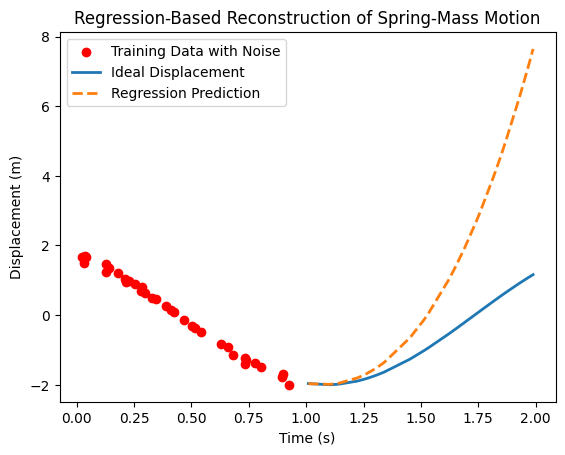

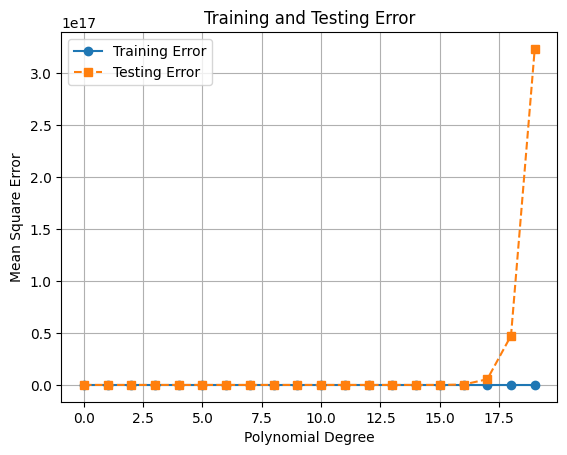

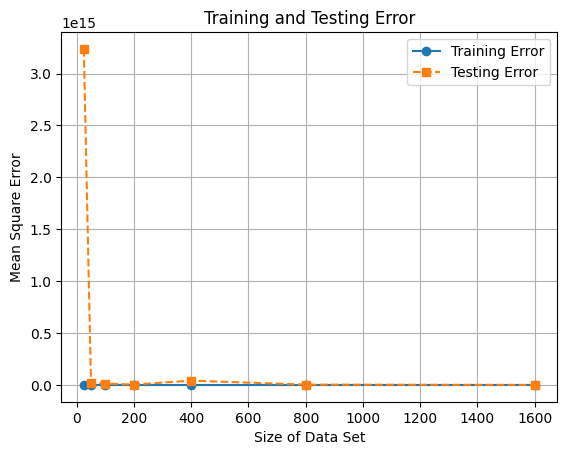

In [ ]:
degree = int(input("Enter degree of polynomial for basis function"))

#Plotting the regression model
pl = Plotting(degree) 

#-------------------------------------------------------------

#Plotting mse vs degree where degree goes from 0 to 20
test_error = np.zeros(20)
train_error = np.zeros(20)

for d1 in range(20):
    Errors = Mean_Square_Errors(d1)
    test_error[d1] = Errors[0]
    #print(test_error)
    train_error[d1] = Errors[1]
   # print(train_error)

degrees = np.arange(0, 20)

plt.plot(degrees, train_error, 'o-', label="Training Error")
plt.plot(degrees, test_error, 's--', label="Testing Error")

plt.xlabel("Polynomial Degree")
plt.ylabel("Mean Square Error")
plt.title("Training and Testing Error")
plt.legend()
plt.grid(True)
#plt.xlim(0,10)
#plt.ylim(-0.5,10)

plt.show()

# ----------------------------------------------------------------

#Plotting Training and Testing Error v/s Data Size
degree = 15
i = 25
k = 0
test_error = np.zeros(7)
train_error = np.zeros(7)
    
while i in range (1600):
    
    train_values = Train_Generate(i) #for value of data size = i, we're finding the training and testing values
    y_train = train_values[0]
    t_train = train_values[1]

    test_values = Test_Generate(i)
    y_test = test_values[0]
    t_test = test_values[1]

    Errors = Mean_Square_Errors(15) #MSE for the above data size with degree = 15
    test_error[k] = Errors[0]
    train_error[k] = Errors[1]

    k = k+1
    i = i*2

#plotting the above
x_axis = [25,50,100,200,400,800,1600]
plt.plot(x_axis, train_error, 'o-', label="Training Error")
plt.plot(x_axis, test_error, 's--', label="Testing Error")

plt.xlabel("Size of Data Set")
plt.ylabel("Mean Square Error")
plt.title("Training and Testing Error")
plt.legend()
plt.grid(True)
plt.show()






